#### Who Worked on this part? 
Muhammad Azaam Ali

# Scrape the data

In [2]:
import pandas as pd
# dont need the file path when the ile exists in the same directory as the script
df = pd.read_csv('mushroom_project_dataset.csv')
df.head()

,cap-diameter,stem-height,stem-width,spore-print-color,gill-color,habitat,season,ring-type,cap-shape,stem-surface,jumbled_noise_0,jumbled_noise_1,class
0,NaN,6.42,13.51,NaN,NaN,d,u,g,x,NaN,x,c,p
1,6.99,7.68,18.76,NaN,w,d,a,f,f,s,f,f,e
2,5.78,7.67,8.21,NaN,r,d,u,f,c,NaN,c,x,p
3,6.34,8.34,11.06,NaN,NaN,d,a,z,x,NaN,x,b,p
4,NaN,5.67,12.78,NaN,n,d,NaN,f,x,NaN,s,s,e


We are seeing some NaN cells means there exists multiple columns with missing data.
### Next steps:
1. Do an EDA to figure to data distibution.
2. Find out which cloumns have the most missing data.
3. Figure out number of classes (just to be sure) and class distribution levels.
3. Find fields directly correlated to the class.

# Brief EDA

C:\Users\azaam\AppData\Local\Temp\ipykernel_36664\1106736180.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  horizontal_ax = sns.countplot(data=df, x='class', palette=['#2ca02c', '#d62728'])


[Text(0.0, 946.5, '37.9%\n1,893'), Text(1.0, 1553.5, '62.1%\n3,107')]

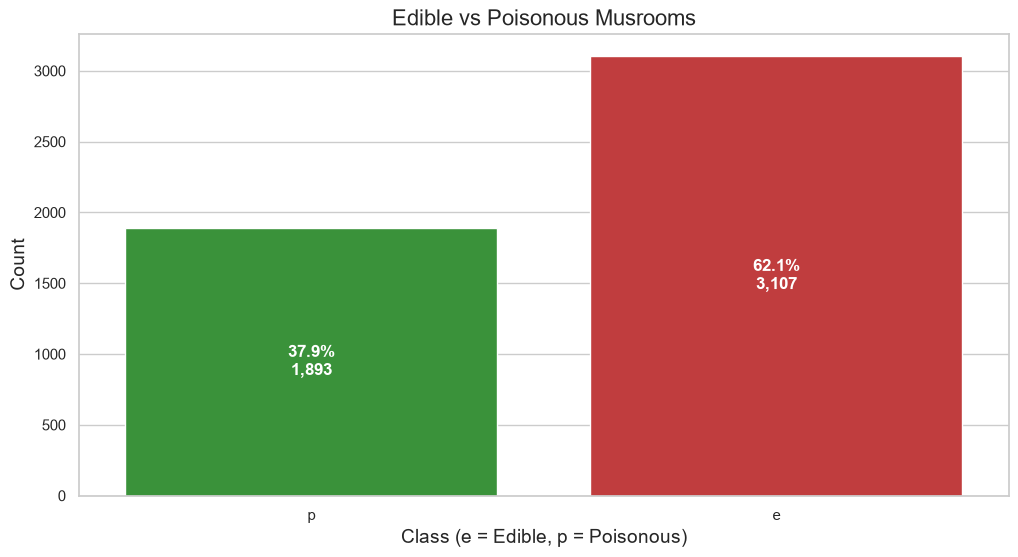

In [3]:
# Finding classes and class distribution
# %pip install seaborn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

horizontal_ax = sns.countplot(data=df, x='class', palette=['#2ca02c', '#d62728'])
plt.title('Edible vs Poisonous Musrooms', fontsize=16)
plt.xlabel('Class (e = Edible, p = Poisonous)', fontsize=14)
plt.ylabel('Count', fontsize=14)

total = len(df)
[horizontal_ax.annotate(
    f'{100 * p.get_height() / total:.1f}%\n{int(p.get_height()):,}', 
    (p.get_x() + p.get_width() / 2., p.get_height() / 2),
       ha='center', va='center', color='white', fontweight='bold', fontsize=12
) for p in horizontal_ax.patches]
# never use fonstsize before or directly after ha, va. attribute 
# error occurs for some reason unknown.



It is confirmed that we have uneven distribution of data in classes. only 2 classes exists p and e, and we have 5000 entries.

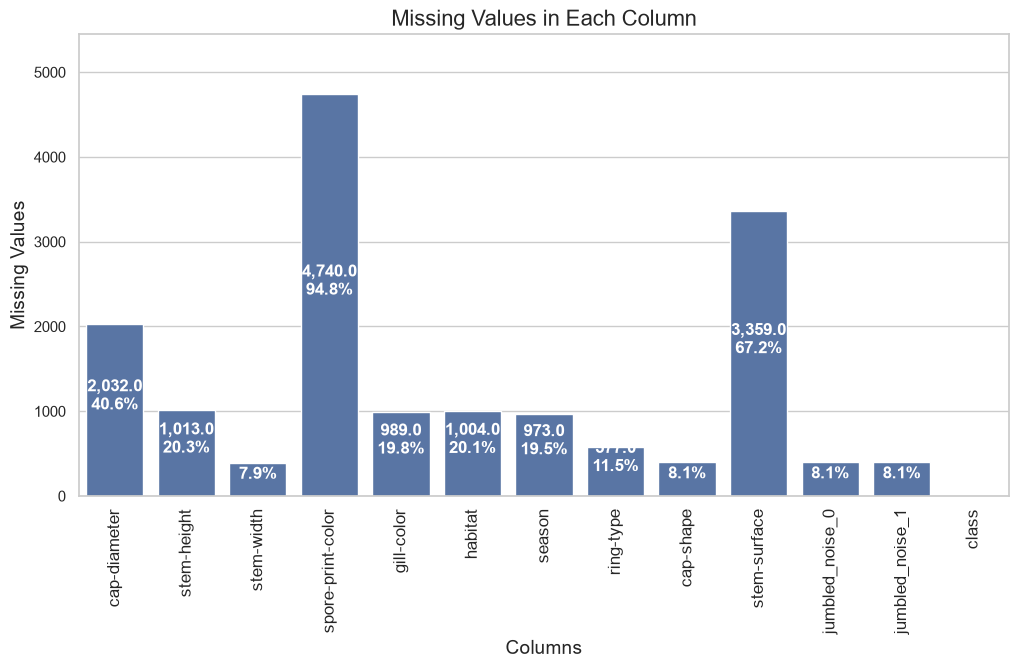

cap-diameter         2032
stem-height          1013
stem-width            395
spore-print-color    4740
gill-color            989
habitat              1004
season                973
ring-type             577
cap-shape             406
stem-surface         3359
jumbled_noise_0       406
jumbled_noise_1       406
class                   0
dtype: int64

In [4]:
# Finding missing values across the columns
missing_values=df.isnull().sum()
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=missing_values.index, y=missing_values.values)
plt.title('Missing Values in Each Column', fontsize=16)
plt.xlabel('Columns', fontsize=14)
plt.ylabel('Missing Values', fontsize=14)
plt.xticks(rotation=90, fontsize=12, ha='center')

# annotate() formatting for the barplot 
[
    ax.annotate(
            f'{p.get_height():,}\n{(p.get_height() / total) * 100:.1f}%' if p.get_height() > 0 else '0',
            (p.get_x() + p.get_width() / 2., p.get_height() / 2),
            ha='center', va='center', color='white', fontweight='bold', fontsize=12,
            xytext=(0, 10), textcoords='offset points'
    ) for p in ax.patches
]
plt.ylim(0, max(missing_values.values) * 1.15)
plt.show()
missing_values


There is a lot data missing from the cells especially in the spore-print-color and the stem-surface. Both of these are 95% and 67% empty respectively and can't be used optimally for the model training part apparently.

Main questions:-
 Is having deliberate missing values adds any value to a mushroom being edible or poisonous?
 Should we add guess values or not? Mainly to see any change in poisonous class specifically.

In [5]:
# Checking if missing values relates to a poisonous class   
is_poisonous = df['class'] == 'p'

# columns that have at least one missing value
missing_cols = [col for col in df.columns if df[col].isna().any()]

# one row per column: % missing, poisonous rate when missing, poisonous rate when present
missing_vs_class = pd.DataFrame(
    [
        {
            'column': col,
            'pct_missing': round(df[col].isna().mean() * 100, 1),
            'poison_rate_missing': round(is_poisonous[df[col].isna()].mean(), 3),
            'poison_rate_present': round(is_poisonous[df[col].notna()].mean(), 3),
        }
        for col in missing_cols
    ]
).set_index('column').sort_values('pct_missing', ascending=False)

missing_vs_class


,pct_missing,poison_rate_missing,poison_rate_present
column,,,
spore-print-color,94.8,0.373,0.488
stem-surface,67.2,0.355,0.428
cap-diameter,40.6,0.383,0.375
stem-height,20.3,0.378,0.379
habitat,20.1,0.402,0.373
gill-color,19.8,0.381,0.378
season,19.5,0.386,0.377
ring-type,11.5,0.362,0.381
jumbled_noise_0,8.1,0.414,0.375


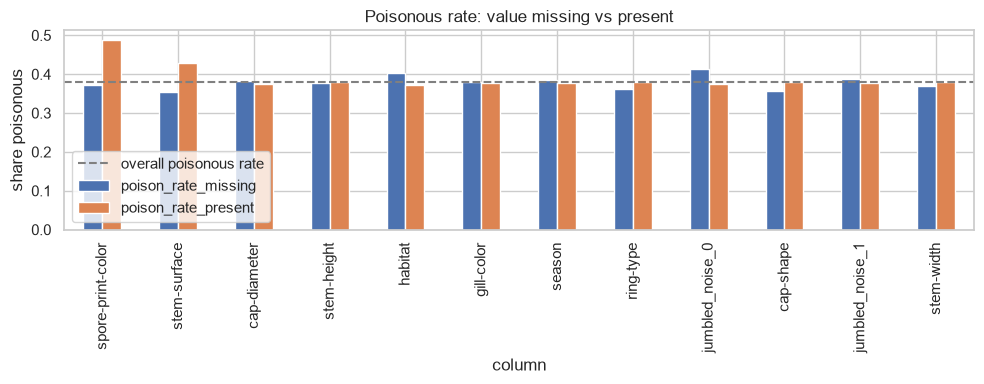

In [6]:
missing_vs_class[['poison_rate_missing', 'poison_rate_present']].plot.bar(figsize=(10, 4))
plt.axhline(is_poisonous.mean(), color='grey', linestyle='--', label='overall poisonous rate')
plt.ylabel('share poisonous')
plt.title('Poisonous rate: value missing vs present')
plt.legend()
plt.tight_layout()
plt.show()

There is not much change when the value is missing or filled overall. THe change visually looks random at best. There is no distinct side dominating the graph.

The spore-print-color and stem-surface have the most significant changes, keeping the fact in mind that they were mostly empty.

Features like cap-diameter, stem-height, stem-width, habitat, season, and ring-type have almost the exact same poisonous rate when present vs. missing (~37%–38%), closely matching the global dataset baseline of 37.9%.

Future prediction: self-guessed values may not help us out much, as the visuals tells the story.

! Delete
Hunch: deleting 2 columns, spore print color and stem-surface, may prove to be beneficial when training model.

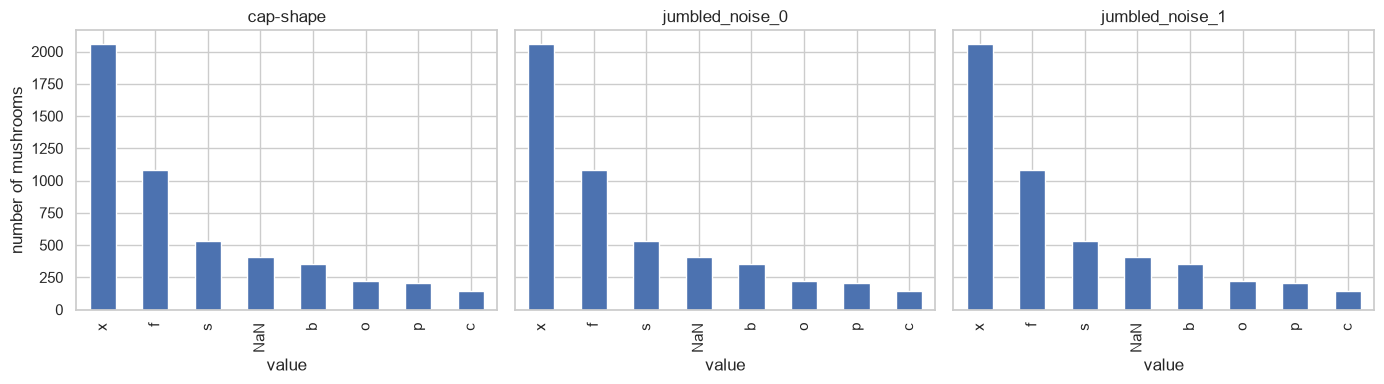

,cap-shape,jumbled_noise_0,jumbled_noise_1
x,2060,2060,2060
f,1078,1078,1078
s,533,533,533
NaN,406,406,406
b,354,354,354
o,218,218,218
p,207,207,207
c,144,144,144


In [7]:
# jumbled_noise columns and cap-shape both share the 
# same number of empty fields (delibrate move?)
# and seeing them in csv make me think they are 
# randomly exchanged value with cap-shape. Nothing to do with real classes.

cols = ['cap-shape', 'jumbled_noise_0', 'jumbled_noise_1']

counts = pd.DataFrame({col: df[col].fillna('NaN').value_counts() for col in cols})

# same value order for all three, most common value first
counts = counts.sort_values('cap-shape', ascending=False)

# one bar chart per column, side by side, same y-axis so they're easy to compare
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, col in zip(axes, cols):
    counts[col].plot.bar(ax=ax, title=col)
    ax.set_xlabel('value')
axes[0].set_ylabel('number of mushrooms')
plt.tight_layout()
plt.show()

counts

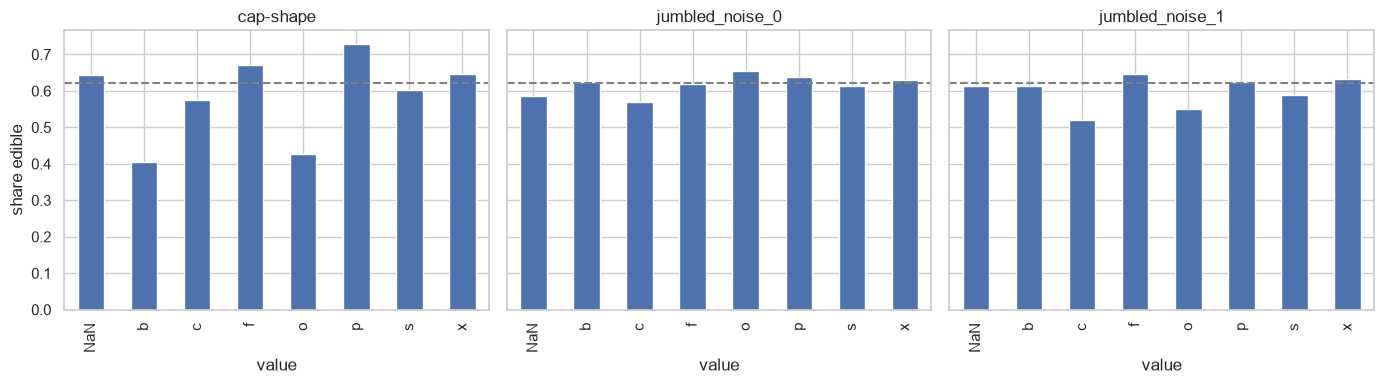

,cap-shape,jumbled_noise_0,jumbled_noise_1
NaN,0.64,0.59,0.61
b,0.40,0.62,0.61
c,0.58,0.57,0.52
f,0.67,0.62,0.65
o,0.43,0.66,0.55
p,0.73,0.64,0.62
s,0.60,0.61,0.59
x,0.65,0.63,0.63


In [16]:
#lets check the edible rate
cols = ['cap-shape', 'jumbled_noise_0', 'jumbled_noise_1']
is_edible = df['class'] == 'e'
edible_rate = pd.DataFrame({col: is_edible.groupby(df[col].fillna('NaN')).mean() for col in cols})

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, col in zip(axes, cols):
    edible_rate[col].plot.bar(ax=ax, title=col)
    ax.axhline(is_edible.mean(), color='grey', linestyle='--')  # overall edible rate (62%)
    ax.set_xlabel('value')
axes[0].set_ylabel('share edible')
plt.tight_layout()
plt.show()

edible_rate.round(2)

It is plausible that the values are randomly and evenly swaped among the said tables and jumbled-noise-0 and jumbled-noise-1 won't add much value or no value when training the models, as current values don't belong to the right mushroom. Keeping only the cap-shap column as it is helps.

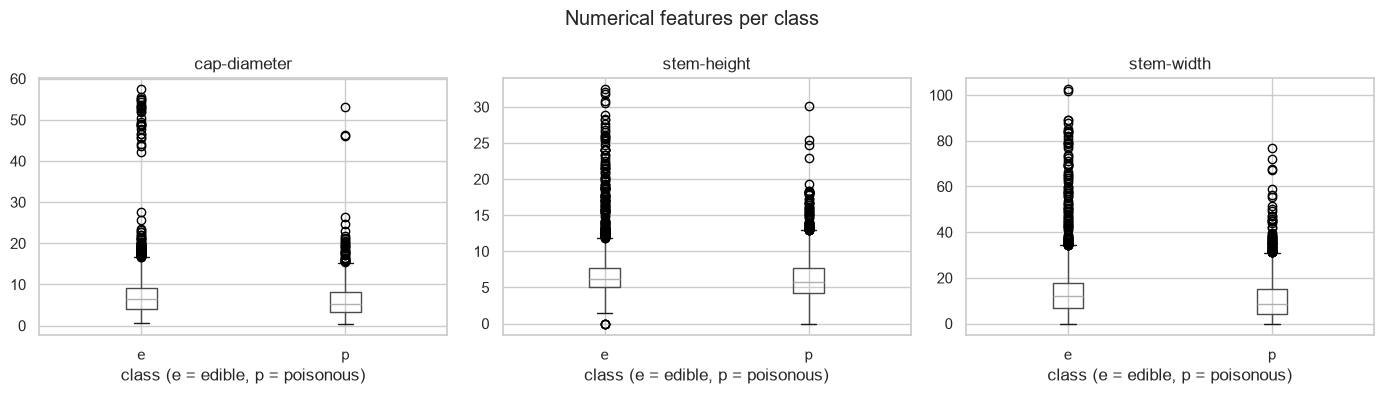

In [18]:
# finding numerical outliers in the columns with numerical values
cols = ['cap-diameter', 'stem-height', 'stem-width']
# df.plot.box(y=cols, title='Boxplots of Numerical Features')

edible = df['class'] == 'e'
poisonous = df['class'] == 'p'

# check numerical outliers for these
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, cols):
    df.boxplot(column=col, by='class', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('class (e = edible, p = poisonous)')
plt.suptitle('Numerical features per class')
plt.tight_layout()
plt.show()


In [19]:
# outlier vs percentile
def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()

def percentile_outliers(s):
    low, high = s.quantile([0.01, 0.99])
    return ((s < low) | (s > high)).sum()

# one row per column and class; quantiles are computed per class here
outliers = pd.DataFrame([
    {
        'column': col,
        'class': name,
        'count': mask_rows.sum(),
        'iqr_outliers': iqr_outliers(df.loc[mask_rows, col].dropna()),
        'pct_outliers': percentile_outliers(df.loc[mask_rows, col].dropna()),
        'max': df.loc[mask_rows, col].max(),
    }
    for col in cols
    for name, mask_rows in [('edible', edible), ('poisonous', poisonous)]
])
outliers


,column,class,count,iqr_outliers,pct_outliers,max
0,cap-diameter,edible,3107,101,38,57.40
1,cap-diameter,poisonous,1893,36,24,53.09
2,stem-height,edible,3107,157,50,32.43
3,stem-height,poisonous,1893,66,16,30.15
4,stem-width,edible,3107,110,57,102.48
5,stem-width,poisonous,1893,71,18,77.00


In [20]:
import numpy as np

pd.DataFrame({
    'skew_original': [df[col].skew() for col in cols],
    'skew_log': [np.log1p(df[col]).skew() for col in cols],
}, index=cols).round(2)


,skew_original,skew_log
cap-diameter,4.23,0.10
stem-height,2.46,-0.76
stem-width,2.60,-0.52


In [ ]:
# does the seasonality of the mushroom affect its edibility? not the case. Toxicity is genetic seasons don't change it.
# season representation: unsure about these(s=spring, u=summer), a=autumn, w=winter
# have to ask teach

## Findings.

# Story